# Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Coleta de Dados

In [ ]:
df = pd.read_csv("Caso_Pratico_base_churn_saas.csv")

## Observação Inicial

In [ ]:
df.head()

,id_cliente,tempo_contrato_meses,plano,regiao,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn
0,C001,12,Básico,Sudeste,15,2,120,0,3,1.8,0
1,C002,3,Premium,Sul,4,6,350,1,8,0.5,1
2,C003,8,Intermediário,Sudeste,10,1,210,0,5,1.2,0
3,C004,24,Premium,Centro-Oeste,25,0,370,0,12,3.5,0
4,C005,6,Básico,Nordeste,6,4,130,1,2,0.9,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              100 non-null    object 
 1   tempo_contrato_meses    100 non-null    int64  
 2   plano                   100 non-null    object 
 3   regiao                  100 non-null    object 
 4   logins_mes              100 non-null    int64  
 5   tickets_suporte         100 non-null    int64  
 6   valor_mensal            100 non-null    int64  
 7   inadimplencia           100 non-null    int64  
 8   qtd_funcionarios        100 non-null    int64  
 9   uso_media_diaria_horas  100 non-null    float64
 10  churn                   100 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 8.7+ KB


In [ ]:
df.describe()

,tempo_contrato_meses,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,9.690000,13.120000,2.570000,204.800000,0.420000,5.340000,1.729000,0.420000
std,6.107943,7.413174,2.370931,97.125141,0.496045,3.736849,1.045461,0.496045
min,1.000000,2.000000,0.000000,100.000000,0.000000,1.000000,0.200000,0.000000
25%,5.000000,6.000000,1.000000,115.000000,0.000000,2.000000,0.800000,0.000000
50%,9.000000,12.500000,1.500000,205.000000,0.000000,5.000000,1.650000,0.000000
75%,13.000000,19.000000,5.000000,240.000000,1.000000,7.000000,2.700000,1.000000
max,30.000000,29.000000,8.000000,400.000000,1.000000,15.000000,4.000000,1.000000


In [ ]:
df.isnull().sum()

,0
id_cliente,0
tempo_contrato_meses,0
plano,0
regiao,0
logins_mes,0
tickets_suporte,0
valor_mensal,0
inadimplencia,0
qtd_funcionarios,0
uso_media_diaria_horas,0


In [ ]:
df.duplicated().sum()

np.int64(0)

*   42% de churn (valor muito alto)

1. Tempo de contrato (clientes novos tendem a cancelar mais)
2. Logins (menos logins mensais tendem a gerar churn)
3. Tickets suporte (muitos tickets podem indicar problemas e podem gerar insatisfação que pode gerar churn)
4. Uso diário (baixo uso diário pode levar a churn)

### gráficos comparativos

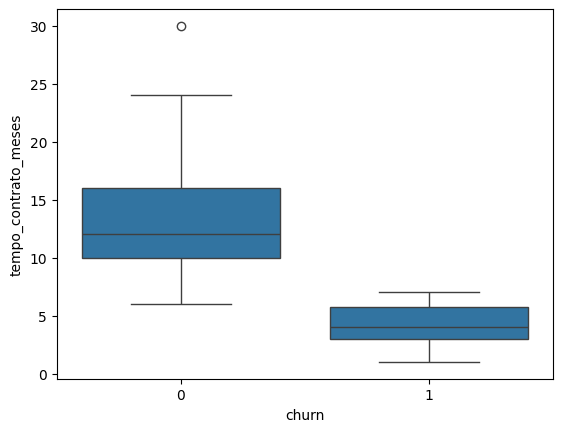

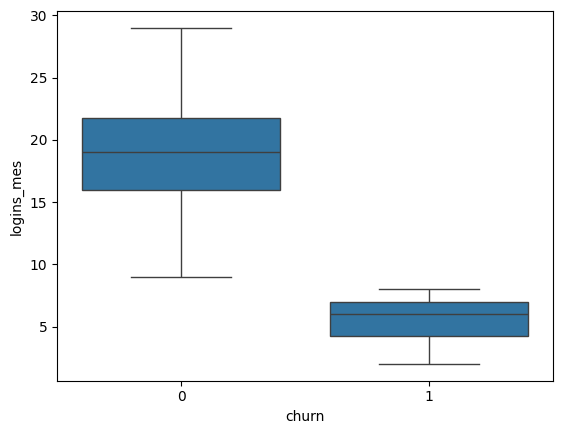

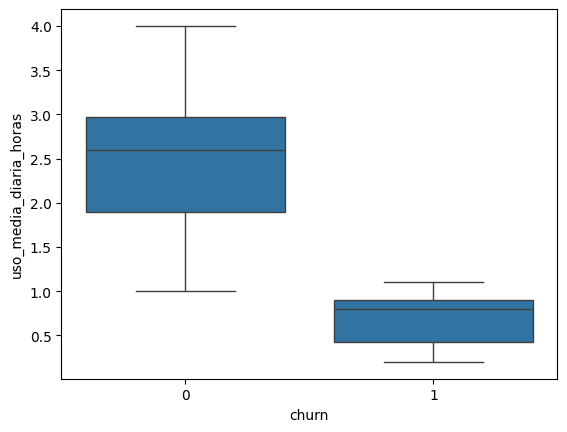

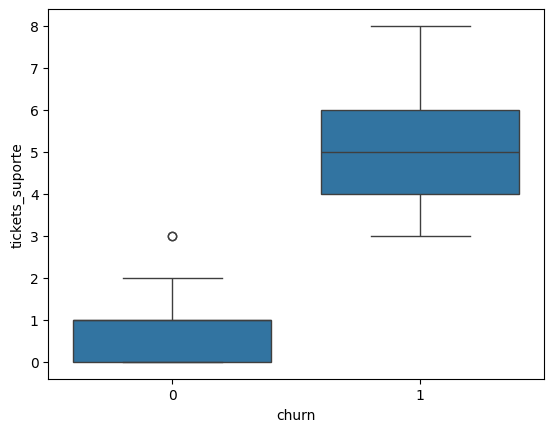

In [ ]:
sns.boxplot(x='churn', y='tempo_contrato_meses', data=df)
plt.show()
# menos meses de contrato, mais churn

sns.boxplot(x='churn', y='logins_mes', data=df)
plt.show()
#menos logins por més, mais churn

sns.boxplot(x='churn', y='uso_media_diaria_horas', data=df)
plt.show()
# menos uso médio diário de horas, mais churn

sns.boxplot(x='churn', y='tickets_suporte', data=df)
plt.show()
#mais tickets de suporte, mais churn

# 2. Trate e prepare os dados

In [ ]:
# Remover id_cliente
df_model = df.drop('id_cliente', axis=1)

In [ ]:
# Aplicando One-Hot Encoding
df_model = pd.get_dummies(df_model, columns=['plano', 'regiao'], drop_first=True)
colunas_bool = df_model.select_dtypes(include='bool').columns
df_model[colunas_bool] = df_model[colunas_bool].astype(int)
df_model.head()

,tempo_contrato_meses,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn,plano_Intermediário,plano_Premium,regiao_Nordeste,regiao_Sudeste,regiao_Sul
0,12,15,2,120,0,3,1.8,0,0,0,0,1,0
1,3,4,6,350,1,8,0.5,1,0,1,0,0,1
2,8,10,1,210,0,5,1.2,0,1,0,0,1,0
3,24,25,0,370,0,12,3.5,0,0,1,0,0,0
4,6,6,4,130,1,2,0.9,1,0,0,1,0,0


As variáveis categóricas foram transformadas utilizando One-Hot Encoding, permitindo sua utilização em modelos de machine learning. Foi utilizado o parâmetro drop_first=True para evitar multicolinearidade.

In [ ]:
# Normalizar Colunas
colunas_para_normalizar = [
    'tempo_contrato_meses',
    'logins_mes',
    'tickets_suporte',
    'valor_mensal',
    'qtd_funcionarios',
    'uso_media_diaria_horas'
]
scaler = StandardScaler()
df_normal = df_model.copy()
df_normal[colunas_para_normalizar] = scaler.fit_transform(df_normal[colunas_para_normalizar])
df_normal.head()

,tempo_contrato_meses,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn,plano_Intermediário,plano_Premium,regiao_Nordeste,regiao_Sudeste,regiao_Sul
0,0.380101,0.254880,-0.241623,-0.877499,0,-0.629351,0.068255,0,0,0,0,1,0
1,-1.100813,-1.236440,1.453977,1.502510,1,0.715416,-1.181480,1,0,1,0,0,1
2,-0.278083,-0.422993,-0.665523,0.053809,0,-0.091444,-0.508546,0,1,0,0,1,0
3,2.354654,1.610626,-1.089423,1.709467,0,1.791229,1.702523,0,0,1,0,0,0
4,-0.607175,-0.965291,0.606177,-0.774020,1,-0.898304,-0.796946,1,0,0,1,0,0


As variáveis numéricas foram padronizadas utilizando StandardScaler, devido à diferença de escala entre elas. Essa etapa é importante para algoritmos de machine learning sensíveis à magnitude dos dados.

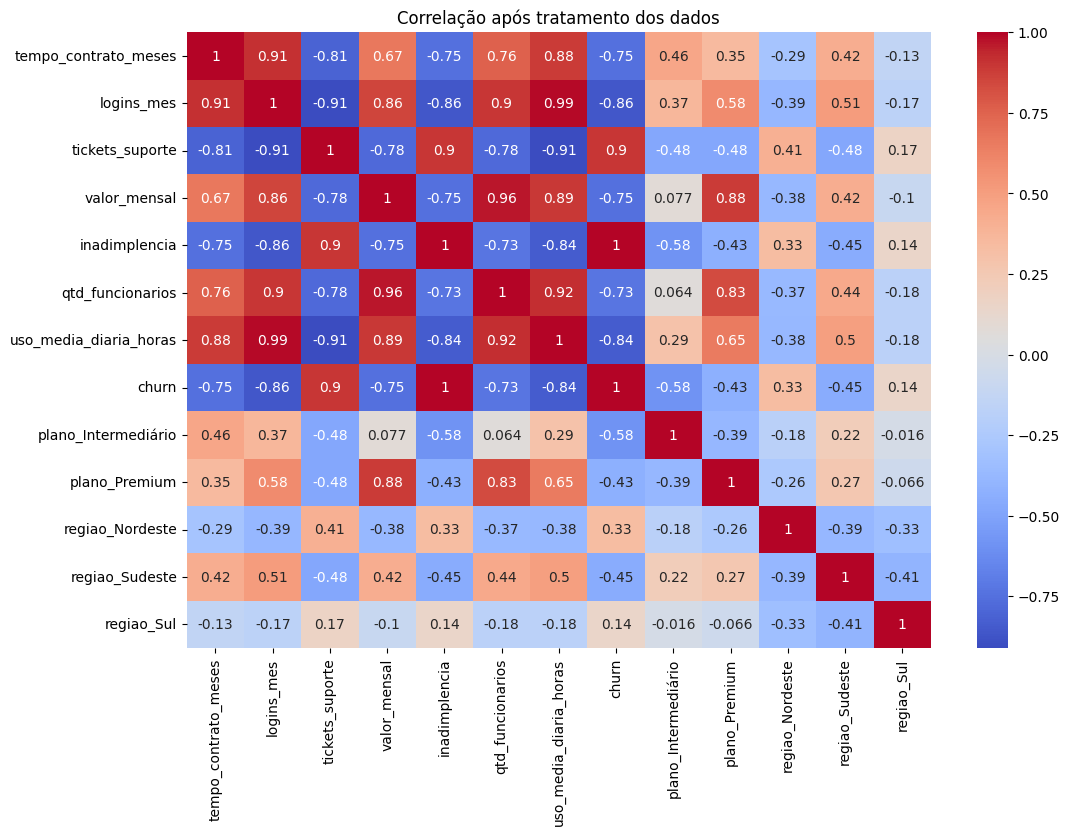

In [ ]:
# Verifique correlações relevantes e elimine colunas redundantes.
plt.figure(figsize=(12,8))
sns.heatmap(df_normal.corr(), annot=True, cmap='coolwarm')
plt.title('Correlação após tratamento dos dados')
plt.show()

In [ ]:
df_sem_redundancia = df_normal.drop(['uso_media_diaria_horas', 'qtd_funcionarios'], axis=1)

A análise de correlação identificou alta multicolinearidade entre algumas variáveis:

- `logins_mes` e `uso_media_diaria_horas` (0.99)
- `valor_mensal` e `qtd_funcionarios` (0.96)

Para evitar redundância, vou remover:

- `uso_media_diaria_horas`, mantendo logins_mes` por maior interpretabilidade
- `qtd_funcionarios`, mantendo `valor_mensal` por maior relevância para o negócio



# 3. Separe os dados em treino e teste

In [ ]:
# Utilize 70% para treino e 30% para teste.
# Defina churn como variável-alvo (target).

X = df_sem_redundancia.drop('churn', axis=1)
y = df_sem_redundancia['churn']

In [ ]:
stratify=y

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(70, 10)
(30, 10)
churn
0    0.585714
1    0.414286
Name: proportion, dtype: float64
churn
0    0.566667
1    0.433333
Name: proportion, dtype: float64


Os dados foram divididos em conjuntos de treino (70%) e teste (30%) utilizando a função train_test_split. Foi utilizado o parâmetro stratify para manter a proporção da variável alvo (churn) em ambos os conjuntos, evitando viés na modelagem.

# 4. Treine os modelos

### Regreção Logistica

In [ ]:
modelo_lr = LogisticRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

### Random Forest

In [ ]:
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

### XGBoost

In [ ]:
modelo_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
modelo_xgb.fit(X_train, y_train)
y_pred_xgb = modelo_xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:51:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# 5 Avalie os resultados

### métricas de classificação

In [ ]:
def avaliar_modelo(nome, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]  # probabilidade de churn

    print(f'--- {nome} ---')
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred))
    print('Recall:', recall_score(y_test, y_pred))
    print('F1-score:', f1_score(y_test, y_pred))
    print('ROC-AUC:', roc_auc_score(y_test, y_proba))
    print()

In [ ]:
avaliar_modelo("Logistic Regression", modelo_lr, X_test, y_test)
avaliar_modelo("Random Forest", modelo_rf, X_test, y_test)
avaliar_modelo("XGBoost", modelo_xgb, X_test, y_test)

--- Logistic Regression ---
Accuracy: 0.9333333333333333
Precision: 0.8666666666666667
Recall: 1.0
F1-score: 0.9285714285714286
ROC-AUC: 1.0

--- Random Forest ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
ROC-AUC: 1.0

--- XGBoost ---
Accuracy: 0.9
Precision: 0.8125
Recall: 1.0
F1-score: 0.896551724137931
ROC-AUC: 0.9117647058823529



Todos os modelos apresentaram alto desempenho, com destaque para o recall igual a 1.0, indicando que todos foram capazes de identificar corretamente os clientes com churn.

Apesar do Random Forest apresentar métricas perfeitas, há indícios de overfitting devido ao tamanho reduzido da base de dados.

### matriz de confusão - Logistic Regression

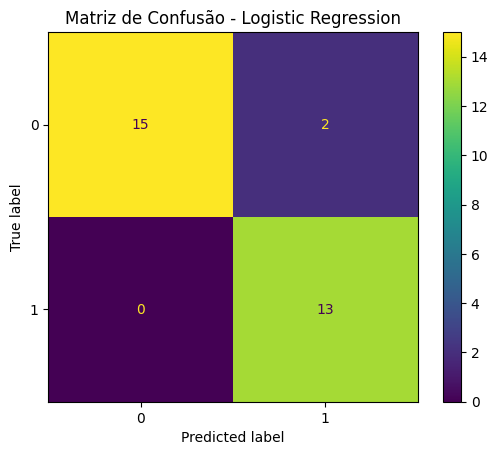

In [ ]:
y_pred = modelo_lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusão - Logistic Regression")
plt.show()

O modelo previu 15 clientes como churn, sendo que 13 realmente cancelaram e 2 foram falsos positivos. Além disso, todos os clientes que não foram classificados como churn realmente permaneceram ativos.

### curva ROC

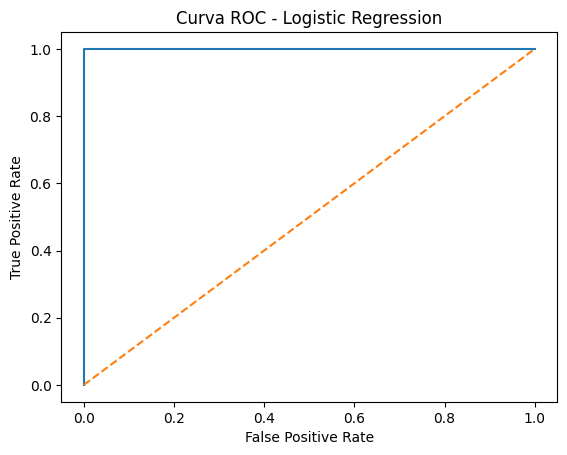

In [ ]:
y_proba = modelo_lr.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')  # linha aleatória
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Logistic Regression')
plt.show()

# 6 Interprete e apresente os resultados

A análise identificou que altos volumes de tickets de suporte e inadimplência são os principais fatores associados ao churn, indicando problemas de experiência e barreiras financeiras.

Além disso, baixo engajamento (logins reduzidos) sugere que parte dos clientes pode não estar extraindo valor do produto, possivelmente por desalinhamento com suas necessidades ou falhas no onboarding.

Observou-se também que clientes com maior tempo de contrato apresentam menor propensão ao churn, indicando que os primeiros meses são críticos para retenção.

Com base nesses insights, recomenda-se:

- Melhorar a experiência do usuário, reduzindo a necessidade de suporte por meio da identificação e correção de problemas recorrentes
Implementar estratégias para reduzir inadimplência, como alertas e flexibilização de pagamento
- Avaliar a adequação do produto ao público-alvo e melhorar o onboarding para aumentar o engajamento
- Focar na retenção nos primeiros meses, com acompanhamento ativo e validação de valor
- Criar incentivos de longo prazo, como benefícios por tempo de uso e estratégias de upgrade de plano